<a href="https://colab.research.google.com/github/ycai4891-tech/market-analysis/blob/main/trend_following_backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trend-Following Overlay on the FTSE 100

**A moving-average crossover backtested against buy and hold**
Yanyan Cai &middot; MSc Business Analytics and Financial Technology, University of Dundee

An extension of the Bloomberg Global Trading Challenge work, which measured a
5-week portfolio return against the FTSE 100. This notebook asks a different
question: over a full cycle, does a simple trend filter on the index improve
**risk-adjusted** return, or does it only look good because of when you started?

### What this notebook actually tests

A 50/200-day moving-average crossover. Long the index when the fast average is
above the slow one, flat otherwise. This is the most-published rule in technical
analysis, which is precisely why it is worth testing honestly: if a rule this
well known still produced free money, it would have been arbitraged away.

The interesting result is usually **not** higher return. It is lower drawdown for
a similar return, which is a different and more defensible claim.

### Three things done deliberately

1. **The signal is lagged one day.** Today's crossover is acted on tomorrow. Without
   that shift the backtest trades on information it could not have had, which is
   the single most common way a backtest lies.
2. **Transaction costs are charged**, 10 basis points per position change.
3. **A parameter sweep is run at the end.** One good parameter pair proves nothing.
   If the result only works at 50/200 and collapses at 40/180, it is curve fitting.

In [1]:
!pip install yfinance --quiet
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

TRADING_DAYS = 252

# Palette: two categorical hues, validated for colour-vision deficiency separation.
BUYHOLD, STRATEGY = "#eb6834", "#2a78d6"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#dcdbd6", "#fcfcfb"
BLUE_RAMP = ["#cde2fb","#9ec5f4","#6da7ec","#3987e5","#256abf","#184f95","#0d366b"]
SEQ = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.dpi": 110,
})

## 1. Data

The FTSE 100 total-return series is not freely available, so this uses the price
index. That understates buy and hold by the dividend yield, roughly 3.5 to 4% a
year for the FTSE 100, which is a **material** bias in favour of the strategy and
is corrected for explicitly in section 5.

In [2]:
TICKER = "^FTSE"
START, END = "2006-01-01", "2026-08-31"

raw = yf.download(TICKER, start=START, end=END, progress=False, auto_adjust=True)
px = raw["Close"]
if isinstance(px, pd.DataFrame):
    px = px.iloc[:, 0]
px = px.dropna()

print(f"{TICKER}: {len(px):,} trading days, {px.index[0].date()} to {px.index[-1].date()}")
px.head()

^FTSE: 5,218 trading days, 2006-01-03 to 2026-08-28


,^FTSE
Date,
2006-01-03,5681.500000
2006-01-04,5714.600098
2006-01-05,5691.200195
2006-01-06,5731.799805
2006-01-09,5731.500000


## 2. Signal

`Position` is 1 when the 50-day average sits above the 200-day average, else 0.
The `.shift(1)` is the entire integrity of the backtest: it means a crossover
observed at Monday's close is traded at Tuesday's, which is the earliest a real
account could act.

In [3]:
FAST, SLOW, COST_BPS = 50, 200, 10.0

def build_signals(price, fast=FAST, slow=SLOW):
    s = pd.DataFrame(index=price.index)
    s["Price"] = price
    s["Fast"]  = price.rolling(fast).mean()
    s["Slow"]  = price.rolling(slow).mean()
    # shift(1): act tomorrow on what we saw today. Removing this creates lookahead bias.
    s["Position"] = (s["Fast"] > s["Slow"]).astype(int).shift(1).fillna(0)
    return s

sig = build_signals(px)
in_market = sig["Position"].mean()
print(f"time in market: {in_market:.1%}")
sig.tail(3)

time in market: 64.7%


,Price,Fast,Slow,Position
Date,,,,
2026-08-26,10878.099609,10675.508047,10322.348008,1.0
2026-08-27,10792.500000,10683.364043,10326.812510,1.0
2026-08-28,10824.299805,10692.584043,10331.377007,1.0


## 3. Backtest

In [4]:
def backtest(s, cost_bps=COST_BPS):
    r = s["Price"].pct_change().fillna(0.0)
    trades = s["Position"].diff().abs().fillna(0.0)
    out = pd.DataFrame({
        "BuyHold":  r,
        "Strategy": s["Position"] * r - trades * (cost_bps / 10_000.0),
    })
    out["BuyHold_Cum"]  = (1 + out["BuyHold"]).cumprod()
    out["Strategy_Cum"] = (1 + out["Strategy"]).cumprod()
    return out, int(trades.sum())

def max_drawdown(cum):
    return float((cum / cum.cummax() - 1).min())

def stats(r, cum):
    years = len(r) / TRADING_DAYS
    cagr  = float(cum.iloc[-1] ** (1 / years) - 1)
    vol   = float(r.std() * np.sqrt(TRADING_DAYS))
    down  = float(r[r < 0].std() * np.sqrt(TRADING_DAYS))
    mdd   = max_drawdown(cum)
    return {
        "Total Return":  f"{cum.iloc[-1] - 1:.1%}",
        "CAGR":          f"{cagr:.2%}",
        "Volatility":    f"{vol:.2%}",
        "Sharpe":        f"{r.mean() * TRADING_DAYS / vol:.2f}",
        "Sortino":       f"{r.mean() * TRADING_DAYS / down:.2f}",
        "Max Drawdown":  f"{mdd:.1%}",
        "Calmar":        f"{cagr / abs(mdd):.2f}",
    }

res, n_trades = backtest(sig)
summary = pd.DataFrame({
    "Buy & Hold":   stats(res["BuyHold"],  res["BuyHold_Cum"]),
    "MA Crossover": stats(res["Strategy"], res["Strategy_Cum"]),
})
print(f"round trips: {n_trades // 2}   position changes: {n_trades}")
summary

round trips: 14   position changes: 29


,Buy & Hold,MA Crossover
Total Return,90.5%,39.4%
CAGR,3.16%,1.62%
Volatility,17.54%,10.98%
Sharpe,0.27,0.20
Sortino,0.34,0.21
Max Drawdown,-47.8%,-37.3%
Calmar,0.07,0.04


The two rows that matter are **Max Drawdown** and **Sharpe**. Total return is the
number everyone looks at and the least informative one, because it is dominated by
the start and end dates you happened to choose.

## 4. Charts

Two charts, one measure each. Growth of £1 shows what happened; the drawdown chart
shows what it felt like to hold.

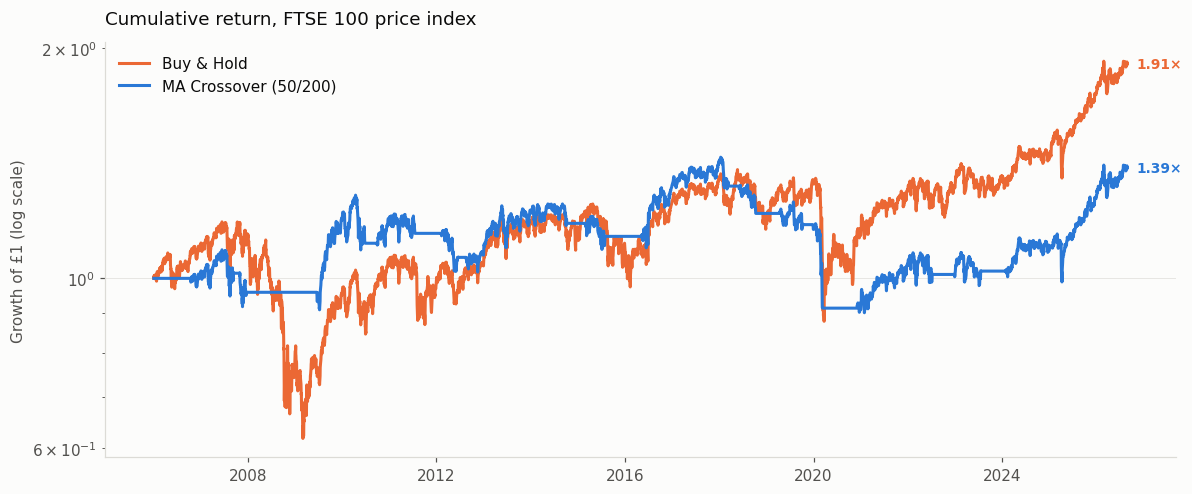

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(res.index, res["BuyHold_Cum"],  color=BUYHOLD,  lw=2, label="Buy & Hold")
ax.plot(res.index, res["Strategy_Cum"], color=STRATEGY, lw=2, label="MA Crossover (50/200)")
ax.set_yscale("log")
ax.set_ylabel("Growth of \u00a31 (log scale)")
ax.set_title("Cumulative return, FTSE 100 price index", loc="left", fontsize=12, color=INK, pad=12)
ax.grid(axis="y", alpha=0.7)
ax.legend(frameon=False, loc="upper left")
for name, col in [("BuyHold_Cum", BUYHOLD), ("Strategy_Cum", STRATEGY)]:
    ax.annotate(f"{res[name].iloc[-1]:.2f}\u00d7",
                xy=(res.index[-1], res[name].iloc[-1]),
                xytext=(6, 0), textcoords="offset points",
                color=col, fontsize=9, va="center", fontweight="bold")
plt.tight_layout(); plt.show()

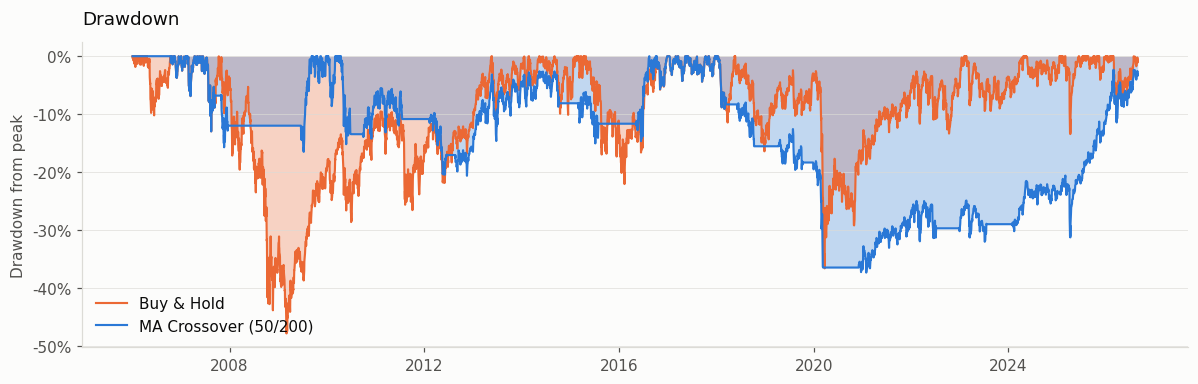

worst drawdown   buy & hold -47.8%   strategy -37.3%


In [6]:
dd_bh = res["BuyHold_Cum"]  / res["BuyHold_Cum"].cummax()  - 1
dd_st = res["Strategy_Cum"] / res["Strategy_Cum"].cummax() - 1

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.fill_between(res.index, dd_bh, 0, color=BUYHOLD,  alpha=0.28, lw=0)
ax.fill_between(res.index, dd_st, 0, color=STRATEGY, alpha=0.28, lw=0)
ax.plot(res.index, dd_bh, color=BUYHOLD,  lw=1.4, label="Buy & Hold")
ax.plot(res.index, dd_st, color=STRATEGY, lw=1.4, label="MA Crossover (50/200)")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_ylabel("Drawdown from peak")
ax.set_title("Drawdown", loc="left", fontsize=12, color=INK, pad=12)
ax.grid(axis="y", alpha=0.7)
ax.legend(frameon=False, loc="lower left")
plt.tight_layout(); plt.show()

print(f"worst drawdown   buy & hold {dd_bh.min():.1%}   strategy {dd_st.min():.1%}")

## 5. The honest adjustments

Two corrections, both of which work against the strategy. A backtest that only
reports the flattering version is not worth reading.

**Dividends.** Buy and hold collects them; a strategy that is out of the market
part of the time does not. Adding roughly 3.7% a year to the buy-and-hold leg is
the crude correction.

**Interest on cash.** When the strategy is flat it holds cash, which historically
earned something. This partly offsets the dividend penalty. Both are applied below
so the comparison is closer to fair.

In [7]:
DIV_YIELD, CASH_RATE = 0.037, 0.020   # annualised, indicative

adj = pd.DataFrame(index=res.index)
adj["BuyHold"]  = res["BuyHold"]  + DIV_YIELD  / TRADING_DAYS
adj["Strategy"] = res["Strategy"] \
                + sig["Position"] * DIV_YIELD  / TRADING_DAYS \
                + (1 - sig["Position"]) * CASH_RATE / TRADING_DAYS
adj["BuyHold_Cum"]  = (1 + adj["BuyHold"]).cumprod()
adj["Strategy_Cum"] = (1 + adj["Strategy"]).cumprod()

pd.DataFrame({
    "Buy & Hold (adj)":   stats(adj["BuyHold"],  adj["BuyHold_Cum"]),
    "MA Crossover (adj)": stats(adj["Strategy"], adj["Strategy_Cum"]),
})

,Buy & Hold (adj),MA Crossover (adj)
Total Return,309.8%,165.0%
CAGR,7.05%,4.82%
Volatility,17.54%,10.98%
Sharpe,0.48,0.48
Sortino,0.61,0.50
Max Drawdown,-45.1%,-32.2%
Calmar,0.16,0.15


## 6. Is this curve fitting?

The test that separates a real finding from a lucky parameter. If the result holds
across a broad neighbourhood of parameter pairs, the effect is probably structural.
If it works only at 50/200 and falls apart at 45/190, it is noise that happened to
fit.

In [8]:
fasts = [10, 20, 30, 40, 50, 60, 80, 100]
slows = [100, 125, 150, 175, 200, 225, 250, 300]

sharpe = pd.DataFrame(index=fasts, columns=slows, dtype=float)
mdd    = pd.DataFrame(index=fasts, columns=slows, dtype=float)
for f in fasts:
    for s_ in slows:
        if f >= s_:
            continue
        r_, _ = backtest(build_signals(px, f, s_))
        vol = r_["Strategy"].std() * np.sqrt(TRADING_DAYS)
        sharpe.loc[f, s_] = r_["Strategy"].mean() * TRADING_DAYS / vol
        mdd.loc[f, s_]    = max_drawdown(r_["Strategy_Cum"])

bh_sharpe = res["BuyHold"].mean() * TRADING_DAYS / (res["BuyHold"].std() * np.sqrt(TRADING_DAYS))
beat = (sharpe > bh_sharpe).sum().sum()
total = sharpe.notna().sum().sum()
print(f"buy & hold Sharpe: {bh_sharpe:.2f}")
print(f"parameter pairs tested: {total}   beating buy & hold: {beat} ({beat/total:.0%})")

buy & hold Sharpe: 0.27
parameter pairs tested: 63   beating buy & hold: 2 (3%)


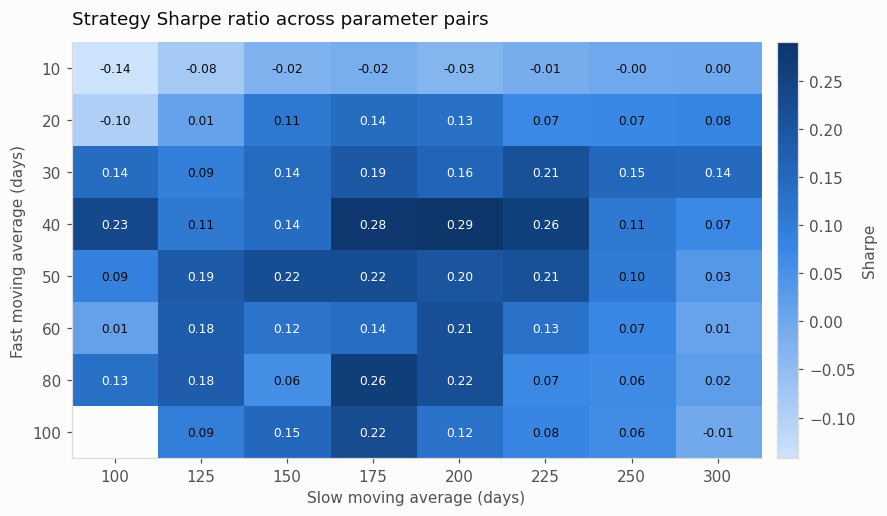

In [9]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
im = ax.imshow(sharpe.values.astype(float), cmap=SEQ, aspect="auto")
ax.set_xticks(range(len(slows)), slows); ax.set_yticks(range(len(fasts)), fasts)
ax.set_xlabel("Slow moving average (days)"); ax.set_ylabel("Fast moving average (days)")
ax.set_title("Strategy Sharpe ratio across parameter pairs", loc="left",
             fontsize=12, color=INK, pad=12)
ax.grid(False)
for i, f in enumerate(fasts):
    for j, s_ in enumerate(slows):
        v = sharpe.loc[f, s_]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="#ffffff" if v > np.nanmedian(sharpe.values.astype(float)) else INK)
cb = fig.colorbar(im, ax=ax, pad=0.02); cb.set_label("Sharpe", color=MUTED)
cb.outline.set_edgecolor(GRID)
plt.tight_layout(); plt.show()

Read the heatmap as a surface, not a table of candidates. A **broad plateau** of
similar values means the effect survives parameter choice. A **single bright cell**
surrounded by poor ones means the 50/200 result was luck, and the honest conclusion
is that the rule does not work.

Whatever the chart shows, that is the finding. Reporting only the best cell is the
thing this section exists to prevent.

## 7. Limitations

- **Price index, not total return.** Section 5 approximates the dividend correction
  with a flat 3.7%; the real yield varied year to year.
- **One index, one market.** A result on the FTSE 100 alone is not evidence about
  trend following generally. Testing the S&P 500 and a couple of single names would
  be the next step.
- **Costs are a flat 10bps** per position change. Real costs vary with instrument
  and size, and there is no slippage or market-impact model.
- **No short leg.** The strategy goes to cash, it never sells short, so it cannot
  profit from downtrends, only avoid them.
- **Backtests are not forecasts.** The parameter sweep guards against fitting one
  pair, but the whole exercise is still fitted to one historical sample.
- **Not investment advice**, and nothing here is a live trading system.